<a href="https://colab.research.google.com/github/Forla03/Deep-Learning-Project---July-2026/blob/main/Deep_Learning_Project_July_Forlani_Francesco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# SETUP

from __future__ import annotations

import json
import os
import random
import shutil
import subprocess
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
# CONFIG

@dataclass(frozen=True)
class Config:
    TRAIN_CSV_PATH: str = "data/white_to_black_train.csv"
    TEST_CSV_PATH: str = "data/white_to_black_test.csv"
    ARTIFACT_DIR: str = "/content/drive/MyDrive/artifacts_2"

    TRAIN_GDRIVE_ID: str = "1aQF9QQO0GgNLgv13bf5BfExaVij2OowX"
    TEST_GDRIVE_ID: str = "1z6ik6MyTjZLVvdsCKTFAgsL6uiSbeKs6"

    MAX_LEN: int = 60
    WHITE_VOCAB_SIZE: int = 20_000
    BLACK_VOCAB_SIZE: int = 20_000

    EMBEDDING_DIM: int = 128
    RNN_UNITS: int = 384
    BOTTLENECK_DIM: int = 256
    DROPOUT: float = 0.25
    SPATIAL_DROPOUT: float = 0.10

    BATCH_SIZE: int = 32
    PREDICTION_BATCH_SIZE: int = 16
    EPOCHS: int = 60
    VALIDATION_FRACTION: float = 0.10
    LEARNING_RATE: float = 1e-3

    SEED: int = 42

    BEST_WEIGHTS_NAME: str = "white_to_black_best.weights.h5"
    FINAL_WEIGHTS_NAME: str = "white_to_black_final.weights.h5"
    METADATA_NAME: str = "white_to_black_metadata.json"


CFG = Config()

## Configuration

This cell centralizes all the main experimental choices used in the notebook: dataset paths, artifact paths, sequence length, vocabulary limits, model capacity, training parameters, and reproducibility settings.

The task is treated as a sequence-to-sequence prediction problem: given the sequence of White SAN moves, the model predicts the aligned sequence of Black SAN moves. The maximum sequence length is fixed to 60 moves.

The vocabulary sizes are defined as upper bounds, the effective vocabularies are later learned only from the training data. This avoids using information from the test set during preprocessing.

The architectural parameters were selected to keep the model below the required trainable-parameter budget while still providing enough capacity for sequential modelling. Dropout and spatial dropout are used as regularization mechanisms.

A fixed random seed is used to make the train/validation split and model training more reproducible. The validation split is used for model selection, while the test set is reserved for final evaluation.

In [4]:
# RUNTIME

def set_reproducibility(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def configure_runtime() -> None:
    gpus = tf.config.list_physical_devices("GPU")

    if gpus:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print(f"GPU detected: {gpus[0].name}")
        print("Mixed precision enabled.")
    else:
        print("No GPU detected. Training will work, but it will be slower.")


set_reproducibility(CFG.SEED)
configure_runtime()

GPU detected: /physical_device:GPU:0
Mixed precision enabled.


## Runtime configuration

This cell sets the random seeds for reproducibility and configures the execution environment. If a GPU is available, mixed precision is enabled to speed up training and reduce memory usage.

In [5]:
# DATASET DOWNLOAD

def install_gdown() -> None:
    try:
        import gdown  # noqa: F401
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "gdown"],
            check=True,
        )


def download_from_gdrive_if_needed(file_id: str, output_path: str) -> None:
    target = Path(output_path)

    if target.exists():
        print(f"Already exists: {target}")
        return

    install_gdown()
    target.parent.mkdir(parents=True, exist_ok=True)

    url = f"https://drive.google.com/uc?id={file_id}"

    subprocess.run(
        [sys.executable, "-m", "gdown", url, "-O", str(target)],
        check=True,
    )

    print(f"Downloaded: {target}")


def ensure_dataset_files(cfg: Config) -> None:
    download_from_gdrive_if_needed(
        cfg.TRAIN_GDRIVE_ID,
        cfg.TRAIN_CSV_PATH,
    )

    download_from_gdrive_if_needed(
        cfg.TEST_GDRIVE_ID,
        cfg.TEST_CSV_PATH,
    )

    print("CSV files:")
    data_dir = Path(cfg.TRAIN_CSV_PATH).parent

    for path in data_dir.glob("*.csv"):
        print(path)


ensure_dataset_files(CFG)

Downloaded: data/white_to_black_train.csv
Downloaded: data/white_to_black_test.csv
CSV files:
data/white_to_black_test.csv
data/white_to_black_train.csv


## Dataset download

This cell downloads the official training and test CSV files from Google Drive if they are not already available locally. The datasets are stored in the paths defined in the configuration.

In [6]:
# LOAD AND CLEAN

def load_and_clean_csv(path: str) -> pd.DataFrame:
    csv_path = Path(path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_columns = {"white", "black"}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing_columns)}")

    df = df[["white", "black"]].dropna().copy()

    df["white"] = df["white"].astype(str).str.strip()
    df["black"] = df["black"].astype(str).str.strip()

    df = df[(df["white"] != "") & (df["black"] != "")].copy()

    white_lengths = df["white"].str.split().str.len()
    black_lengths = df["black"].str.split().str.len()

    df = df[white_lengths == black_lengths].reset_index(drop=True)

    if df.empty:
        raise ValueError(f"No valid rows after cleaning {path}.")

    return df


def load_data(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = load_and_clean_csv(cfg.TRAIN_CSV_PATH)
    test_df = load_and_clean_csv(cfg.TEST_CSV_PATH)

    print(f"Train rows: {len(train_df):,}")
    print(f"Test rows:  {len(test_df):,}")
    print("Average train length:", round(train_df["white"].str.split().str.len().mean(), 2))

    return train_df, test_df


train_df, test_df = load_data(CFG)

display(train_df.head())
display(test_df.head())

Train rows: 101,364
Test rows:  17,888
Average train length: 33.18


,white,black
0,e4 d4 Bd3 Qe2 c4 Nc3 h4 Bf4 Qd2 Nf3 Rh3 Bxh6 R...,b6 Bb7 Nf6 e6 Be7 O-O h6 d6 Ng4 Nd7 e5 Nxh6 Bx...
1,e4 d4 e5 Nf3 c3 a3 b3 cxd4 Bd2 Bc3 Be2 Nxe5 O-...,c6 e6 d5 c5 Nc6 Qb6 cxd4 Qa5+ Qb6 f6 fxe5 Bd6 ...
2,c4 b4 cxd5 d4 Ba3 e3 Bb2 Nf3 Ne5 Nxd7 Bb5 O-O ...,c6 d5 cxd5 a5 e6 axb4 Bd7 Bd6 Nc6 Qxd7 Nge7 O-...
3,e4 Nf3 d4 c3 e5 Bb5 Qa4 Bxc6+ gxf3 e6+ Qxc6+ c...,Nc6 e5 exd4 d5 Bg4 f6 Bxf3 Kf7 bxc6 Kxe6 Kf7 B...
4,e4 f3 d3 e5 f4 exf6 c3 b4 Nh3 g4 gxf5 Ng5 Ne6 ...,Nf6 d5 e6 Nfd7 f6 Bb4+ Ba5 Bb6 gxf6 f5 exf5 h6...


,white,black
0,e3 Qf3 e4 exd5 Bc4 Nc3 Ne4 Bxe6 Nxf6+ Qh5+ Qg4...,d5 e5 Nf6 Nxd5 Nf6 c6 Be6 fxe6 Qxf6 g6 Nd7 Bc5...
1,d4 c4 Nc3 e4 Bd3 Nge2 O-O f4 a3 fxe5 d5 Nxd4 N...,d6 e6 Nf6 g6 Bg7 O-O Nc6 Re8 e5 dxe5 Nd4 exd4 ...
2,d4 c4 Nc3 Nf3 Bg5 e3 Bd3 O-O Bxc4 Bd3 a3 Rc1 N...,Nf6 g6 d5 Bg7 c6 O-O e6 dxc4 b5 a6 Bb7 Nbd7 Rc...
3,e4 Nf3 d4 dxe5 Qxd8+ Nxe5 c3 Nc4 Be3 Be2 Nbd2 ...,e5 Nc6 d6 dxe5 Nxd8 Bb4+ Bd6 Bc5 Ne6 Nf6 b5 Nx...
4,e4 d3 Nd2 Ngf3 g3 Bg2 O-O Re1 b3 Bb2 c3 a3 b4 ...,b6 Bb7 Nf6 e6 Be7 h6 O-O d6 e5 Nbd7 c6 d5 dxe4...


## Data loading and cleaning

This cell loads the official training and test CSV files and performs basic consistency checks.

Only the required columns, `white` and `black`, are kept. Rows with missing or empty move sequences are removed. Since the task is formulated as an aligned sequence-to-sequence problem, each White move must correspond to exactly one Black move. For this reason, games where the number of White and Black moves is different are discarded.

This cleaning step ensures that the model can be trained with one target Black token for each input White token. The test set is cleaned with the same deterministic rules, without using it for model selection.

count    101364.000000
mean         33.181938
std          14.227148
min           5.000000
25%          23.000000
50%          31.000000
75%          43.000000
max          60.000000
Name: white, dtype: float64


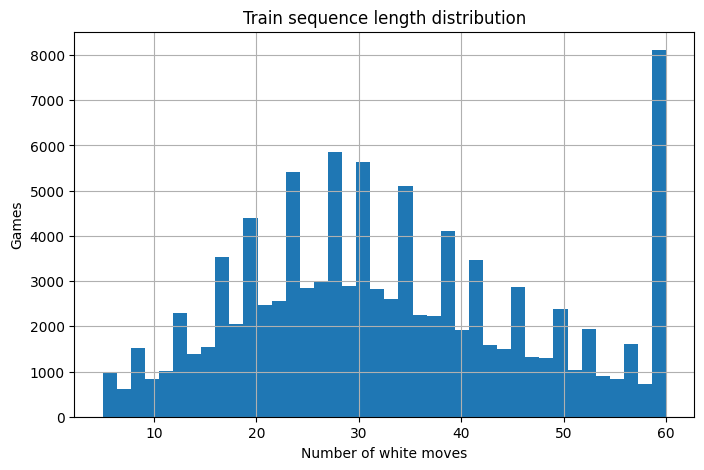

In [7]:
# LENGTH ANALYSIS

lengths = train_df["white"].str.split().str.len()

print(lengths.describe())

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=40)
plt.xlabel("Number of white moves")
plt.ylabel("Games")
plt.title("Train sequence length distribution")
plt.grid(True)
plt.show()

## Length analysis

This cell analyzes the distribution of game lengths in the cleaned training set. Since the model uses fixed-length input and output sequences, the maximum sequence length must be chosen before vectorization.

The cleaned training set has an average length of about 33 White moves, with a median of 31 moves. The maximum observed length is 60 moves, which matches the `MAX_LEN` value used in the configuration. Therefore, `MAX_LEN = 60` preserves the full available move sequences in the cleaned dataset while keeping the recurrent model and the autoregressive evaluation computationally manageable.

The histogram also shows that most games are shorter than the maximum length, so padding is required. Padding tokens are later ignored during training through sample weights.

In [8]:
# TRAIN / VALIDATION SPLIT

def split_train_validation(
    dataframe: pd.DataFrame,
    validation_fraction: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = dataframe.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_size = max(1, int(len(shuffled) * validation_fraction))

    val_df = shuffled.iloc[:val_size].reset_index(drop=True)
    fit_df = shuffled.iloc[val_size:].reset_index(drop=True)

    return fit_df, val_df


fit_df, val_df = split_train_validation(
    train_df,
    validation_fraction=CFG.VALIDATION_FRACTION,
    seed=CFG.SEED,
)

print(f"Fit rows:        {len(fit_df):,}")
print(f"Validation rows: {len(val_df):,}")

Fit rows:        91,228
Validation rows: 10,136


In [9]:
# VECTORIZERS

def create_vectorizer(
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    return keras.layers.TextVectorization(
        max_tokens=max_tokens,
        standardize=None,
        split="whitespace",
        output_mode="int",
        output_sequence_length=max_len,
        name=name,
    )


def adapt_vectorizers(
    dataframe: pd.DataFrame,
    cfg: Config,
) -> tuple[keras.layers.TextVectorization, keras.layers.TextVectorization]:
    white_vectorizer = create_vectorizer(
        max_tokens=cfg.WHITE_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="white_vectorizer",
    )

    black_vectorizer = create_vectorizer(
        max_tokens=cfg.BLACK_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="black_vectorizer",
    )

    white_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["white"].to_numpy()
    ).batch(1024)

    black_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["black"].to_numpy()
    ).batch(1024)

    white_vectorizer.adapt(white_ds)
    black_vectorizer.adapt(black_ds)

    print(f"White vocabulary size: {len(white_vectorizer.get_vocabulary()):,}")
    print(f"Black vocabulary size: {len(black_vectorizer.get_vocabulary()):,}")

    return white_vectorizer, black_vectorizer


white_vectorizer, black_vectorizer = adapt_vectorizers(train_df, CFG)

black_vocabulary = black_vectorizer.get_vocabulary()
BLACK_VOCAB_SIZE_EFF = len(black_vocabulary)
START_ID = BLACK_VOCAB_SIZE_EFF

print("Effective black vocabulary size:", BLACK_VOCAB_SIZE_EFF)
print("START_ID:", START_ID)

White vocabulary size: 4,363
Black vocabulary size: 5,115
Effective black vocabulary size: 5115
START_ID: 5115


## Vectorization

This cell converts SAN move sequences into fixed-length integer sequences. No text standardization is applied because SAN notation contains meaningful symbols such as captures, checks, checkmates, castling marks, and promotions. Moves are therefore split only by whitespace.

Separate vectorizers are used for White and Black moves, since the input and output vocabularies are related but not necessarily identical. The vocabulary is built from the full official training set, the test set remains completely unseen during this preprocessing step.

The effective vocabulary sizes are printed after adaptation. A custom `START_ID` token is then defined outside the Black vocabulary and is used as the initial decoder input for teacher forcing during training and autoregressive generation during inference.

In [10]:
# TENSORFLOW DATASET

def make_decoder_input(
    y: np.ndarray,
    start_id: int,
) -> np.ndarray:
    start_column = np.full(
        shape=(y.shape[0], 1),
        fill_value=start_id,
        dtype="int32",
    )

    return np.concatenate(
        [start_column, y[:, :-1]],
        axis=1,
    )


def vectorize_dataframe(
    dataframe: pd.DataFrame,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
    start_id: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_white = white_vectorizer(
        tf.constant(dataframe["white"].to_numpy())
    ).numpy().astype("int32")

    y = black_vectorizer(
        tf.constant(dataframe["black"].to_numpy())
    ).numpy().astype("int32")

    x_black_shifted = make_decoder_input(
        y=y,
        start_id=start_id,
    )

    sample_weight = (y != 0).astype("float32")

    return x_white, x_black_shifted, y, sample_weight


def make_dataset(
    x_white: np.ndarray,
    x_black_shifted: np.ndarray,
    y: np.ndarray,
    sample_weight: np.ndarray,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "white_tokens": x_white,
                "black_tokens_shifted": x_black_shifted,
            },
            y,
            sample_weight,
        )
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(x_white), 20_000),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


x_train_white, x_train_black_shifted, y_train, sw_train = vectorize_dataframe(
    dataframe=fit_df,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    start_id=START_ID,
)

x_val_white, x_val_black_shifted, y_val, sw_val = vectorize_dataframe(
    dataframe=val_df,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    start_id=START_ID,
)

train_ds = make_dataset(
    x_white=x_train_white,
    x_black_shifted=x_train_black_shifted,
    y=y_train,
    sample_weight=sw_train,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    seed=CFG.SEED,
)

val_ds = make_dataset(
    x_white=x_val_white,
    x_black_shifted=x_val_black_shifted,
    y=y_val,
    sample_weight=sw_val,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    seed=CFG.SEED,
)

print("x_train_white:", x_train_white.shape)
print("x_train_black_shifted:", x_train_black_shifted.shape)
print("y_train:", y_train.shape)

x_train_white: (91228, 60)
x_train_black_shifted: (91228, 60)
y_train: (91228, 60)


## TensorFlow datasets

This cell prepares the numerical tensors used to train the sequence-to-sequence model.

The task is formulated as conditional sequence generation: the encoder receives the full sequence of White moves, while the decoder learns to generate the corresponding sequence of Black moves. During training, the decoder is given the previous ground-truth Black move as input. This strategy is called teacher forcing.

Teacher forcing is used because it makes training more stable and efficient: at each position, the model learns to predict the next Black move given the White sequence and the correct previous Black moves, instead of having to rely on its own early predictions while it is still untrained. For example, if the target sequence is `[b1, b2, b3]`, the decoder input becomes `[START, b1, b2]`, and the target remains `[b1, b2, b3]`.

At inference time, ground-truth Black moves are not available. Therefore, the model is later evaluated autoregressively: it starts from `START_ID` and feeds its own predicted Black moves back into the decoder.

Padding tokens are ignored through `sample_weight`, so the loss is computed only on real moves and not on padded positions.

The data is finally wrapped into `tf.data.Dataset` objects. This avoids repeated tokenization during training and improves efficiency through batching, shuffling, and prefetching.

In [11]:
# MODEL

def build_seq2seq_model(
    white_vocab_size: int,
    black_vocab_size: int,
    cfg: Config,
) -> tuple[keras.Model, keras.Model]:
    encoder_inputs = keras.Input(
        shape=(cfg.MAX_LEN,),
        dtype="int32",
        name="white_tokens",
    )

    enc_emb = keras.layers.Embedding(
        input_dim=white_vocab_size,
        output_dim=cfg.EMBEDDING_DIM,
        mask_zero=True,
        name="white_embedding",
    )(encoder_inputs)

    enc_emb = keras.layers.SpatialDropout1D(
        cfg.SPATIAL_DROPOUT,
        name="encoder_embedding_dropout",
    )(enc_emb)

    encoder_outputs, fwd_h, bwd_h = keras.layers.Bidirectional(
        keras.layers.GRU(
            cfg.RNN_UNITS,
            return_sequences=True,
            return_state=True,
            dropout=cfg.DROPOUT,
            recurrent_dropout=0.0,
        ),
        name="encoder_bigru",
    )(enc_emb)

    encoder_state = keras.layers.Concatenate(
        name="encoder_state_concat",
    )([fwd_h, bwd_h])

    decoder_init_state = keras.layers.Dense(
        cfg.RNN_UNITS,
        activation="tanh",
        name="decoder_init",
    )(encoder_state)

    decoder_inputs = keras.Input(
        shape=(cfg.MAX_LEN,),
        dtype="int32",
        name="black_tokens_shifted",
    )

    dec_emb = keras.layers.Embedding(
        input_dim=black_vocab_size + 1,
        output_dim=cfg.EMBEDDING_DIM,
        name="black_embedding",
    )(decoder_inputs)

    decoder_gru_input = keras.layers.Concatenate(
        axis=-1,
        name="decoder_gru_input",
    )([dec_emb, encoder_outputs])

    decoder_seq, _ = keras.layers.GRU(
        cfg.RNN_UNITS,
        return_sequences=True,
        return_state=True,
        dropout=cfg.DROPOUT,
        recurrent_dropout=0.0,
        name="decoder_gru",
    )(
        decoder_gru_input,
        initial_state=decoder_init_state,
    )

    # Mask to avoid that cross attention looks at the padding of the white sequence.
    encoder_attention_mask = keras.layers.Lambda(
        lambda tokens: tf.expand_dims(tf.not_equal(tokens, 0), axis=1),
        name="encoder_attention_mask",
    )(encoder_inputs)

    # Cross-attention
    attention_context = keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10,
        name="cross_attention",
    )(
        query=decoder_seq,
        value=encoder_outputs,
        key=encoder_outputs,
        attention_mask=encoder_attention_mask,
    )

    # Residual connection + normalization
    x = keras.layers.Add(
        name="decoder_attention_residual",
    )([decoder_seq, attention_context])

    x = keras.layers.LayerNormalization(
        name="decoder_attention_norm",
    )(x)

    x = keras.layers.Dense(
        cfg.BOTTLENECK_DIM,
        activation="gelu",
        name="move_bottleneck",
    )(x)

    x = keras.layers.Dropout(
        cfg.DROPOUT,
        name="bottleneck_dropout",
    )(x)

    outputs = keras.layers.Dense(
        black_vocab_size,
        activation="softmax",
        dtype="float32",
        name="black_move",
    )(x)

    model = keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="white_to_black_seq2seq_cross_attention",
    )

    encoder_model = keras.Model(
        inputs=encoder_inputs,
        outputs=[encoder_outputs, decoder_init_state],
        name="white_to_black_encoder",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=cfg.LEARNING_RATE,
            clipnorm=1.0,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="token_acc"),
        ],
    )

    return model, encoder_model


def count_trainable_parameters(model: keras.Model) -> int:
    return int(
        np.sum([
            np.prod(weight.shape)
            for weight in model.trainable_weights
        ])
    )


def assert_parameter_budget(
    model: keras.Model,
    max_trainable_params: int = 6_000_000,
) -> None:
    trainable_params = count_trainable_parameters(model)

    print(f"Trainable parameters: {trainable_params:,}")

    if trainable_params >= max_trainable_params:
        raise ValueError(
            f"Model has {trainable_params:,} trainable parameters. "
            f"It must stay below {max_trainable_params:,}."
        )


model, encoder_model = build_seq2seq_model(
    white_vocab_size=len(white_vectorizer.get_vocabulary()),
    black_vocab_size=len(black_vectorizer.get_vocabulary()),
    cfg=CFG,
)

model.summary()
assert_parameter_budget(model)

Model: "white_to_black_seq2seq_cross_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ white_tokens        │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ white_embedding     │ (None, 60, 128)   │    558,464 │ white_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding_… │ (None, 60, 128)   │          0 │ white_embedding[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60)        │          0 │ white_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_tokens_shift… │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bigru       │ [(None, 60, 768), │  1,184,256 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 384),      │            │ not_equal[0][0]   │
│                     │ (None, 384)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_embedding     │ (None, 60, 128)   │    654,848 │ black_tokens_shi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_conc… │ (None, 768)       │          0 │ encoder_bigru[0]… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru_input   │ (None, 60, 896)   │          0 │ black_embedding[… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_init        │ (None, 384)       │    295,296 │ encoder_state_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 60, 384), │  1,476,864 │ decoder_gru_inpu… │
│                     │ (None, 384)]      │            │ decoder_init[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_attention_… │ (None, 1, 60)     │          0 │ white_tokens[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ (None, 60, 384)   │    295,680 │ encoder_attentio… │
│ (MultiHeadAttentio… │                   │            │ encoder_bigru[0]… │
│                     │                   │            │ decoder_gru[0][0… │
│                     │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_attention_… │ (None, 60, 384)   │          0 │ decoder_gru[0][0… │
│ (Add)               │                   │            │ cross_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_attention_… │ (None, 60, 384)   │        768 │ decoder_attentio… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ move_bottleneck     │ (None, 60, 256)   │     98,560 │ decoder_attentio

 Total params: 5,879,291 (22.43 MB)

 Trainable params: 5,879,291 (22.43 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 5,879,291


## Model with cross-attention

The model is designed as an encoder-decoder architecture for conditional sequence generation. The input sequence contains the White SAN moves, while the output sequence contains the aligned Black SAN moves.

The encoder first maps White move tokens into dense embeddings. A bidirectional GRU is then used to process the full White sequence both forward and backward. This is useful because the prediction of a Black move may depend not only on the immediately corresponding White move, but also on the broader context of the game, such as previous captures, castling rights, checks, or piece development.

The decoder receives the shifted Black sequence during training, following the teacher forcing setup described above. Its initial hidden state is obtained from the final encoder state, so generation is conditioned on the encoded White sequence from the beginning.

In addition to the decoder state, the model uses two forms of conditioning on the encoder outputs. First, the decoder input is concatenated with the encoder output at the same position, giving the decoder direct access to position-level information. Second, a multi-head cross-attention layer allows each decoder step to dynamically attend to all White moves, instead of looking only at the aligned position. This is important because a Black move can depend on information appearing several moves earlier in the game.

A padding mask is used in the cross-attention layer so that the decoder cannot attend to padded White positions. The attention output is combined with the decoder sequence through a residual connection and layer normalization, which helps preserve the recurrent decoder representation while adding global contextual information from the encoder.

The final dense bottleneck and dropout layers reduce the representation before the softmax classifier over the Black move vocabulary. Dropout and spatial dropout are used to regularize the model.

The architecture is explicitly checked against the project constraint on the maximum number of trainable parameters. The separate `encoder_model` is built to support autoregressive inference: at test time, only the White sequence is encoded, and Black moves are generated step by step from the `START_ID` token.

In [12]:
#TRAINING

def train_model(
    model: keras.Model,
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    cfg: Config,
) -> keras.callbacks.History:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    best_weights_path = artifact_dir / cfg.BEST_WEIGHTS_NAME

    callbacks = [
        keras.callbacks.TerminateOnNaN(),

        keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            min_delta=1e-4,
            patience=4,
            restore_best_weights=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            min_delta=1e-4,
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            mode="min",
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS,
        callbacks=callbacks,
    )

    if best_weights_path.exists():
        model.load_weights(str(best_weights_path))

    return history


history = train_model(model, train_ds, val_ds, CFG)

Epoch 1/60
2851/2851 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2.5493 - token_acc: 0.0876
Epoch 1: val_loss improved from None to 1.77103, saving model to /content/drive/MyDrive/artifacts_2/white_to_black_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/artifacts_2/white_to_black_best.weights.h5
2851/2851 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - loss: 2.1987 - token_acc: 0.1226 - val_loss: 1.7710 - val_token_acc: 0.1736 - learning_rate: 0.0010
Epoch 2/60
2851/2851 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.8188 - token_acc: 0.1640
Epoch 2: val_loss improved from 1.77103 to 1.57865, saving model to /content/drive/MyDrive/artifacts_2/white_to_black_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/artifacts_2/white_to_black_best.weights.h5
2851/2851 ━━━━━━━━━━━━━━━━━━━━ 160s 56ms/step - loss: 1.7768 - token_acc: 0.1698 - val_loss: 1.5787 - val_token_acc: 0.1988 - learning_rate: 0.0010
Epoch 3/60
2851/2851 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - 

## Training procedure

The model is trained on the fit subset and monitored on the validation subset. The validation loss is used to control training because it provides a stable token-level objective for checkpointing and early stopping.

A `ModelCheckpoint` callback saves only the best weights according to validation loss. This avoids keeping a worse model from the final epoch and also preserves the best checkpoint during long runs.

`EarlyStopping` stops training when the validation loss no longer improves by at least `1e-4` for several epochs. This reduces unnecessary computation and helps limit overfitting.

`ReduceLROnPlateau` lowers the learning rate when validation loss stagnates. This allows the optimizer to continue improving with smaller updates after the initial fast learning phase.

At the end of training, the best saved weights are reloaded before evaluation.

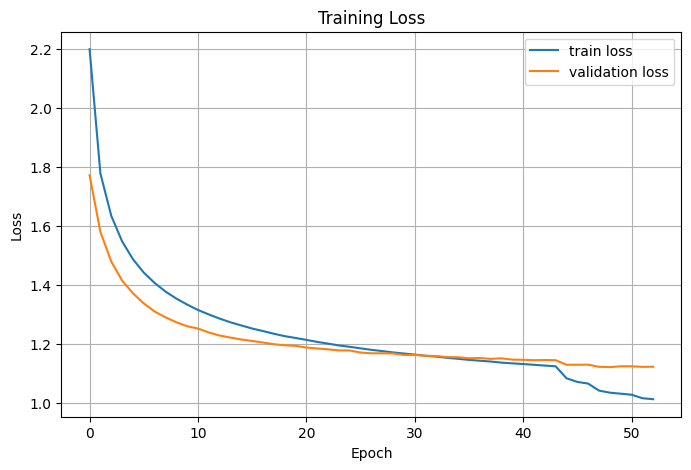

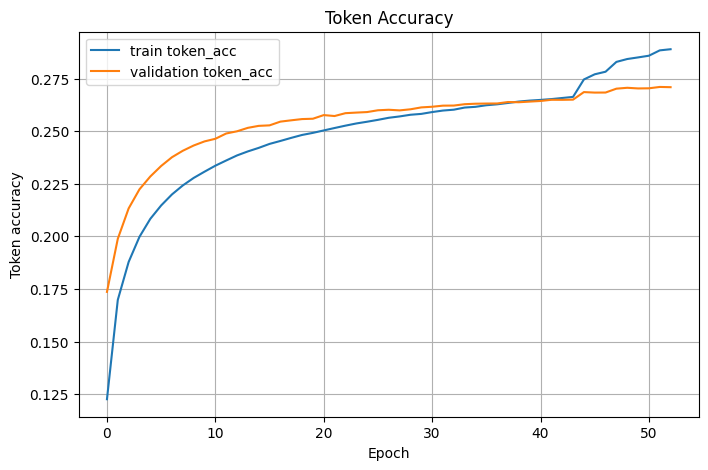

In [13]:
# TRAINING PLOTS

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["token_acc"], label="train token_acc")
plt.plot(history_df["val_token_acc"], label="validation token_acc")
plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.title("Token Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# INFERENCE

def ids_to_tokens(
    ids: list[int],
    vocabulary: list[str],
    limit: int,
) -> list[str]:
    decoded: list[str] = []

    for token_id in ids[:limit]:
        token_id = int(token_id)

        if token_id <= 0 or token_id >= len(vocabulary):
            break

        token = vocabulary[token_id]

        if token == "":
            break

        decoded.append(token)

    return decoded


def get_decoder_layers(
    model: keras.Model,
) -> tuple[
    keras.layers.Embedding,
    keras.layers.GRU,
    keras.layers.MultiHeadAttention,
    keras.layers.LayerNormalization,
    keras.layers.Dense,
    keras.layers.Dropout,
    keras.layers.Dense,
]:
    black_embedding = model.get_layer("black_embedding")
    decoder_gru = model.get_layer("decoder_gru")
    cross_attention = model.get_layer("cross_attention")
    attention_norm = model.get_layer("decoder_attention_norm")
    bottleneck_dense = model.get_layer("move_bottleneck")
    bottleneck_dropout = model.get_layer("bottleneck_dropout")
    output_dense = model.get_layer("black_move")

    return (
        black_embedding,
        decoder_gru,
        cross_attention,
        attention_norm,
        bottleneck_dense,
        bottleneck_dropout,
        output_dense,
    )


def generate_black_moves_batch(
    white_texts: list[str],
    model: keras.Model,
    encoder_model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[list[str]]:
    (
        black_embedding,
        decoder_gru,
        cross_attention,
        attention_norm,
        bottleneck_dense,
        bottleneck_dropout,
        output_dense,
    ) = get_decoder_layers(model)

    x_white = white_vectorizer(
        tf.constant(white_texts)
    ).numpy().astype("int32")

    batch_size = x_white.shape[0]

    white_lengths = np.array([
        min(len(text.split()), cfg.MAX_LEN)
        for text in white_texts
    ])

    encoder_outputs, state = encoder_model(
        x_white,
        training=False,
    )

    attention_mask = tf.expand_dims(
    tf.not_equal(tf.constant(x_white), 0),
    axis=1,
    )

    prev_token = tf.fill(
        dims=(batch_size, 1),
        value=tf.constant(start_id, dtype=tf.int32),
    )

    generated_ids: list[list[int]] = [
        []
        for _ in range(batch_size)
    ]

    finished = np.zeros(batch_size, dtype=bool)

    for timestep in range(cfg.MAX_LEN):
        for sample_index in range(batch_size):
            if timestep >= white_lengths[sample_index]:
                finished[sample_index] = True

        if finished.all():
            break

        emb = black_embedding(prev_token)
        emb = emb[:, 0, :]

        enc_t = encoder_outputs[:, timestep, :]

        step_input = tf.concat(
            [emb, enc_t],
            axis=-1,
        )

        cell_output, new_states = decoder_gru.cell(
            step_input,
            states=[state],
            training=False,
        )

        state = new_states[0]

        query = tf.expand_dims(cell_output, axis=1)

        attention_context = cross_attention(
            query=query,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=attention_mask,
            training=False,
        )

        attention_context = attention_context[:, 0, :]

        h = attention_norm(cell_output + attention_context)

        h = bottleneck_dense(h)
        h = bottleneck_dropout(h, training=False)

        probabilities = output_dense(h).numpy()
        predicted_ids = np.argmax(probabilities, axis=-1).astype("int32")

        for sample_index in range(batch_size):
            if finished[sample_index]:
                continue

            token_id = int(predicted_ids[sample_index])

            if token_id <= 0 or token_id >= len(black_vocabulary):
                finished[sample_index] = True
                continue

            token = black_vocabulary[token_id]

            if token == "":
                finished[sample_index] = True
                continue

            generated_ids[sample_index].append(token_id)

        prev_token = tf.constant(
            predicted_ids.reshape(-1, 1),
            dtype=tf.int32,
        )

    decoded_batch = [
        ids_to_tokens(
            ids=ids,
            vocabulary=black_vocabulary,
            limit=white_lengths[index],
        )
        for index, ids in enumerate(generated_ids)
    ]

    return decoded_batch


def predict_black_moves_batch(
    model: keras.Model,
    encoder_model: keras.Model,
    white_texts: list[str],
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[list[str]]:
    return generate_black_moves_batch(
        white_texts=white_texts,
        model=model,
        encoder_model=encoder_model,
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=cfg,
        start_id=start_id,
    )


def predict_black_moves(
    model: keras.Model,
    encoder_model: keras.Model,
    white_text: str,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[str]:
    return predict_black_moves_batch(
        model=model,
        encoder_model=encoder_model,
        white_texts=[white_text],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=cfg,
        start_id=start_id,
    )[0]

## Inference

During training, the decoder uses teacher forcing and receives the shifted ground-truth Black sequence. At inference time, however, the true Black moves are not available. Therefore, prediction must be performed autoregressively.

The encoder first processes the full sequence of White moves. The decoder then starts from the custom `START_ID` token and generates one Black move at a time. After each step, the predicted Black move is fed back as the next decoder input. This ensures that the final evaluation uses only the White move sequence as external input.

Since the model was trained on full sequences, inference manually reuses the trained decoder layers step by step. At each timestep, the decoder GRU state is updated, and the cross-attention layer allows the current decoder state to attend to all encoder outputs from the White sequence. A padding mask prevents the attention mechanism from using padded White positions.

Predictions are obtained greedily by selecting the most probable Black move at each step. This deterministic decoding strategy was chosen for simplicity, reproducibility, and direct compatibility with the Survival AUC metric.

Finally, generated token IDs are decoded back into SAN move strings. This keeps the evaluation and error inspection human-readable, as required by the project instructions.

In [15]:
# SURVIVAL AUC

def correct_prefix_length(
    true_tokens: list[str],
    predicted_tokens: list[str],
) -> int:
    correct = 0

    for true_token, predicted_token in zip(
        true_tokens,
        predicted_tokens,
        strict=False,
    ):
        if true_token != predicted_token:
            break

        correct += 1

    return correct


def batched_ranges(
    length: int,
    batch_size: int,
) -> list[tuple[int, int]]:
    return [
        (start, min(start + batch_size, length))
        for start in range(0, length, batch_size)
    ]


def evaluate_survival_auc(
    dataframe: pd.DataFrame,
    model: keras.Model,
    encoder_model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
    max_examples: int | None = None,
) -> dict[str, Any]:
    eval_df = dataframe if max_examples is None else dataframe.head(max_examples)
    eval_df = eval_df.reset_index(drop=True)

    prefix_lengths: list[int] = []

    token_correct = 0
    token_total = 0
    first_move_correct = 0
    exact_sequence_correct = 0

    for start, end in batched_ranges(
        len(eval_df),
        cfg.PREDICTION_BATCH_SIZE,
    ):
        batch = eval_df.iloc[start:end]

        predictions = predict_black_moves_batch(
            model=model,
            encoder_model=encoder_model,
            white_texts=batch["white"].tolist(),
            white_vectorizer=white_vectorizer,
            black_vocabulary=black_vocabulary,
            cfg=cfg,
            start_id=start_id,
        )

        for true_text, predicted_tokens in zip(
            batch["black"].tolist(),
            predictions,
            strict=False,
        ):
            true_tokens = true_text.split()[:cfg.MAX_LEN]
            predicted_tokens = predicted_tokens[:len(true_tokens)]

            prefix_len = correct_prefix_length(
                true_tokens=true_tokens,
                predicted_tokens=predicted_tokens,
            )

            prefix_lengths.append(prefix_len)

            first_move_correct += int(prefix_len >= 1)
            exact_sequence_correct += int(prefix_len == len(true_tokens))

            for true_token, predicted_token in zip(
                true_tokens,
                predicted_tokens,
                strict=False,
            ):
                token_correct += int(true_token == predicted_token)
                token_total += 1

    max_curve_len = min(
        cfg.MAX_LEN,
        max((len(text.split()) for text in eval_df["black"]), default=0),
    )

    survival_curve = {
        int(k): float(np.mean([
            prefix_len >= k
            for prefix_len in prefix_lengths
        ]))
        for k in range(1, max_curve_len + 1)
    }

    survival_auc = float(np.mean(prefix_lengths)) if prefix_lengths else 0.0

    return {
        "n_examples": int(len(eval_df)),
        "survival_auc": survival_auc,
        "mean_correct_prefix": survival_auc,
        "first_move_accuracy": (
            float(first_move_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "exact_sequence_accuracy": (
            float(exact_sequence_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "token_accuracy": (
            float(token_correct / token_total)
            if token_total
            else 0.0
        ),
        "survival_curve": survival_curve,
        "prefix_lengths": prefix_lengths,
    }


def print_metrics(metrics: dict[str, Any]) -> None:
    print(f"Examples:                {metrics['n_examples']:,}")
    print(f"Survival AUC:            {metrics['survival_auc']:.4f}")
    print(f"First move accuracy:     {metrics['first_move_accuracy']:.4f}")
    print(f"Token accuracy:          {metrics['token_accuracy']:.4f}")
    print(f"Exact sequence accuracy: {metrics['exact_sequence_accuracy']:.4f}")


def plot_survival_curve(metrics: dict[str, Any]) -> None:
    curve = metrics["survival_curve"]

    if not curve:
        print("No survival curve available.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(list(curve.keys()), list(curve.values()), marker="o")
    plt.xlabel("k")
    plt.ylabel("S(k)")
    plt.title("Survival Curve")
    plt.grid(True)
    plt.show()

## Survival AUC evaluation

This cell implements the main evaluation protocol used in the project.

For each game, the model predicts the sequence of Black moves autoregressively from the White move sequence. The prediction is then compared with the true Black sequence from the beginning. The correct prefix length is the number of consecutive Black moves predicted correctly before the first mistake.

The Survival AUC is computed as the average correct prefix length over all evaluated games. This metric is stricter than token accuracy because a mistake at an early move stops the correct prefix, even if later moves happen to match.

The survival curve `S(k)` reports the fraction of games for which at least the first `k` Black moves are predicted correctly. Additional metrics are also reported for interpretation: first move accuracy, token accuracy, and exact sequence accuracy.

Validation metrics
Examples:                10,136
Survival AUC:            2.2395
First move accuracy:     0.6776
Token accuracy:          0.2433
Exact sequence accuracy: 0.0022


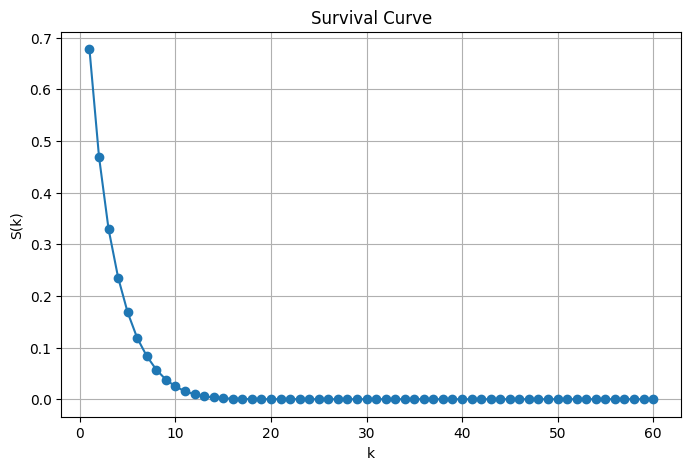

In [16]:
# FINAL VALIDATION

print("Validation metrics")

val_metrics = evaluate_survival_auc(
    dataframe=val_df,
    model=model,
    encoder_model=encoder_model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    start_id=START_ID,
    max_examples=None,
)

print_metrics(val_metrics)
plot_survival_curve(val_metrics)


Full test metrics
Examples:                17,888
Survival AUC:            2.2696
First move accuracy:     0.6736
Token accuracy:          0.2452
Exact sequence accuracy: 0.0021


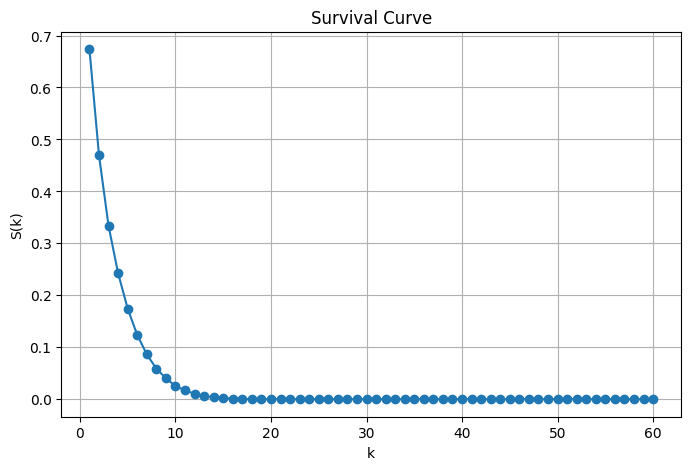

In [17]:
# FINAL TEST

print("\nFull test metrics")

test_metrics = evaluate_survival_auc(
    dataframe=test_df,
    model=model,
    encoder_model=encoder_model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    start_id=START_ID,
    max_examples=None,
)

print_metrics(test_metrics)
plot_survival_curve(test_metrics)

## Final validation and test evaluation

The validation set is used to compare candidate models and check whether architectural or training changes improve the main project metric, Survival AUC.
The evaluation is performed autoregressively on decoded SAN moves, using only the White move sequence as input.

The official test set is evaluated only after selecting the final model from the validation results.
This cell reports the final performance using the same autoregressive decoding procedure and the same Survival AUC metric used on validation.

In [18]:
# RANDOM EXAMPLES

sample_df = test_df.sample(
    n=min(5, len(test_df)),
    random_state=CFG.SEED,
)

for _, row in sample_df.iterrows():
    predicted_black = predict_black_moves(
        model=model,
        encoder_model=encoder_model,
        white_text=row["white"],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=CFG,
        start_id=START_ID,
    )

    print("=" * 100)
    print("White:      ", row["white"])
    print("True black: ", row["black"])
    print("Pred black: ", " ".join(predicted_black))

White:       e4 Nf3 Bb5 O-O c3 Ba4 Bb3 Bc2 Re1 h3 d4 Qxf3 d5 b4 Bg5 Nd2 cxb4 Nf1 bxc5 Ng3 Be3 Nf5 Nxe7 Qf5+ Qf3 Qg3
True black:  e5 Nc6 d6 Bd7 a6 b5 Na5 Nf6 Bg4 Bh5 Bxf3 Be7 O-O Nb7 a5 axb4 Qd7 c5 Nxc5 h6 b4 Kh7 Qxe7 g6 Kg7 Nfxe4
Pred black:  e5 Nc6 Nge7 d6 a6 b5 Na5 Bb7 Ng6 Be7 Bxf3 O-O c5 c4 a5 axb4 f6 c5 dxc5 h6 Kh7 Nh8 Qxe7 Ng6 Nh4 Ng6
White:       e4 Nf3 Nc3 d4 Nxd4 Nxc6 Qd4 Be3 Bxd4 e5 Nxd5 Bd3 Be3 Be4 Bc1 O-O f4 exd6 Bc6 Ba4 Rf2 b3 Rf1 Rxe1 Kf2 Kg3 Bb2 Bxa1 Bd7 Kg4 h3 Bf5 Kxh5 c3
True black:  e5 Nc6 Nf6 exd4 Qe7 bxc6 Qc5 Qxd4 Be7 Nd5 cxd5 c5 d4 Rb8 O-O Re8 d6 Bxd6 Re2 Bb7 Rbe8 Re1+ R8e2 Rxe1+ Rh1 Rg1 Rxa1 g5 Bxf4+ Bxg2 Be4 h5+ Bxf5 d3
Pred black:  c5 Nc6 e6 cxd4 Qb6 bxc6 Bc5 Bxd4 Nf6 Nd5 cxd5 O-O d4 Rb8 Bb7 d6 Rfe8 Qxd6 Bxc6 Bd5 Qb6 Qb2 Qxe1+ Rxe1+ Rc2+ Rxa2 Ra1 Rxa1 Ra3+ h6 a5 h5+ a4 a3
White:       d4 c4 e3 cxd5 Nc3 a3 b4 Bb2 Nf3 Qc2 Bd3 Ng5 h3 f4 g4 hxg4 Be2 Nd1 Nxe3 Bc1 Qxc6 Qxa8+ Rxc1 axb4 Kf1 Qb7 Ke1 Bd1 Qxd5 Be2 Qd2 Kd1 Kc2 Qd4+ Qd2+ Qc3 Bd3 Kb3 Qc1+ Qxh1+ Qc6 Qd7+
True b

In [19]:
# ARTIFACTS SAVING

def extract_metric_summary(metrics: dict[str, Any]) -> dict[str, float]:
    return {
        "survival_auc": float(metrics["survival_auc"]),
        "first_move_accuracy": float(metrics["first_move_accuracy"]),
        "token_accuracy": float(metrics["token_accuracy"]),
        "exact_sequence_accuracy": float(metrics["exact_sequence_accuracy"]),
    }


def save_artifacts(
    model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
    cfg: Config,
    start_id: int,
    val_metrics: dict[str, Any] | None = None,
    test_metrics: dict[str, Any] | None = None,
) -> tuple[Path, Path]:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    final_weights_path = artifact_dir / cfg.FINAL_WEIGHTS_NAME
    metadata_path = artifact_dir / cfg.METADATA_NAME

    model.save_weights(str(final_weights_path))

    metadata = {
        "model_type": "seq2seq_teacher_forcing",
        "config": asdict(cfg),
        "start_id": int(start_id),
        "white_vocabulary": white_vectorizer.get_vocabulary(),
        "black_vocabulary": black_vectorizer.get_vocabulary(),
        "final_metrics": {
            "validation": (
                extract_metric_summary(val_metrics)
                if val_metrics is not None
                else None
            ),
            "test": (
                extract_metric_summary(test_metrics)
                if test_metrics is not None
                else None
            ),
        },
    }

    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(f"Saved weights:  {final_weights_path}")
    print(f"Saved metadata: {metadata_path}")

    return final_weights_path, metadata_path


final_weights_path, metadata_path = save_artifacts(
    model=model,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    cfg=CFG,
    start_id=START_ID,
    val_metrics=val_metrics,
    test_metrics=globals().get("test_metrics"),
)

Saved weights:  /content/drive/MyDrive/artifacts_2/white_to_black_final.weights.h5
Saved metadata: /content/drive/MyDrive/artifacts_2/white_to_black_metadata.json


## Compliance with project constraints

The model is trained only on the official training CSV provided with the project. No external chess games or data augmentation are used.

The official test set is never used for training, validation, vocabulary selection, or model selection. It is used only once for the final evaluation.

The model is implemented entirely in Keras and is designed to run on Google Colab. The total number of trainable parameters is reported explicitly and checked programmatically to remain below the 6 million parameter limit.

Although teacher forcing is used during training, final validation and test evaluation are performed autoregressively. At inference time, the model receives only the White move sequence and generates Black moves step by step from its own previous predictions.

The final metric is computed on decoded SAN move strings, as required by the project instructions.

In [20]:
# ARTIFACT LOADING UTILITIES

def load_vectorizer_from_vocabulary(
    vocabulary: list[str],
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    vectorizer = create_vectorizer(
        max_tokens=max_tokens,
        max_len=max_len,
        name=name,
    )

    vectorizer.set_vocabulary(vocabulary)

    return vectorizer


def load_config_from_metadata(metadata_config: dict[str, Any]) -> Config:
    valid_config_keys = set(Config.__dataclass_fields__.keys())

    clean_config = {
        key: value
        for key, value in metadata_config.items()
        if key in valid_config_keys
    }

    return Config(**clean_config)


def load_artifacts(
    artifact_dir: str,
    weights_name: str | None = None,
    metadata_name: str | None = None,
) -> tuple[
    keras.Model,
    keras.Model,
    keras.layers.TextVectorization,
    keras.layers.TextVectorization,
    Config,
    int,
]:
    artifact_path = Path(artifact_dir)
    metadata_path = artifact_path / (metadata_name or CFG.METADATA_NAME)

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    loaded_cfg = load_config_from_metadata(metadata["config"])

    if weights_name is not None:
        loaded_cfg = Config(
            **{
                **asdict(loaded_cfg),
                "FINAL_WEIGHTS_NAME": weights_name,
            }
        )

    loaded_white_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["white_vocabulary"],
        max_tokens=loaded_cfg.WHITE_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="white_vectorizer",
    )

    loaded_black_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["black_vocabulary"],
        max_tokens=loaded_cfg.BLACK_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="black_vectorizer",
    )

    loaded_model, loaded_encoder_model = build_seq2seq_model(
        white_vocab_size=len(metadata["white_vocabulary"]),
        black_vocab_size=len(metadata["black_vocabulary"]),
        cfg=loaded_cfg,
    )

    loaded_model.load_weights(
        str(artifact_path / loaded_cfg.FINAL_WEIGHTS_NAME)
    )

    loaded_start_id = int(metadata.get(
        "start_id",
        len(metadata["black_vocabulary"]),
    ))

    return (
        loaded_model,
        loaded_encoder_model,
        loaded_white_vectorizer,
        loaded_black_vectorizer,
        loaded_cfg,
        loaded_start_id,
    )

In [21]:
# GDOWN VERIFICATION CELL

GDOWN_CHECK_DIR = Path("gdown_check")
GDOWN_CHECK_DIR.mkdir(parents=True, exist_ok=True)

FINAL_WEIGHTS_GDRIVE_ID = "1RJdta2QQMM32Tsn2hOG7JgXOJxuV0QH3"
METADATA_GDRIVE_ID = "1sbg__SY_zJD5zIsU1dUA3WzTh7O8wXIU"

download_from_gdrive_if_needed(
    FINAL_WEIGHTS_GDRIVE_ID,
    str(GDOWN_CHECK_DIR / CFG.FINAL_WEIGHTS_NAME),
)

download_from_gdrive_if_needed(
    METADATA_GDRIVE_ID,
    str(GDOWN_CHECK_DIR / CFG.METADATA_NAME),
)

(
    gdown_model,
    gdown_encoder_model,
    gdown_white_vectorizer,
    gdown_black_vectorizer,
    gdown_cfg,
    gdown_start_id,
) = load_artifacts(str(GDOWN_CHECK_DIR))

assert_parameter_budget(gdown_model)

sample_white = test_df.iloc[0]["white"]

sample_prediction = predict_black_moves(
    model=gdown_model,
    encoder_model=gdown_encoder_model,
    white_text=sample_white,
    white_vectorizer=gdown_white_vectorizer,
    black_vocabulary=gdown_black_vectorizer.get_vocabulary(),
    cfg=gdown_cfg,
    start_id=gdown_start_id,
)

print("gdown verification completed successfully.")
print("White:", sample_white)
print("Predicted black:", " ".join(sample_prediction))

Downloaded: gdown_check/white_to_black_final.weights.h5
Downloaded: gdown_check/white_to_black_metadata.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Trainable parameters: 5,879,291
gdown verification completed successfully.
White: e3 Qf3 e4 exd5 Bc4 Nc3 Ne4 Bxe6 Nxf6+ Qh5+ Qg4 Nf3 b3 Bb2 O-O-O Kxb2 c3 gxf3 Qa4 b4 Ka1 Rhe1 Rxd1 b5
Predicted black: d5 e6 c5 exd5 Be6 d4 Be7 fxe6 gxf6 Kf8 Nc6 e5 Bd6 Qc7 Bxb2+ e4 exf3 Nge7 Rd8 c4 d3 Rxd1+ Nf5 Nfd4


## Final artifacts and gdown verification

The final trained weights and metadata are stored on Google Drive and can be downloaded using `gdown`.

- Weights file ID: `1RJdta2QQMM32Tsn2hOG7JgXOJxuV0QH3`
- Metadata file ID: `1sbg__SY_zJD5zIsU1dUA3WzTh7O8wXIU`

The cell verifies that the files can be downloaded from Google Drive and that the model can be reconstructed and used for inference.